# Iris Dataset Exploratory Data Analysis (EDA)

## Project Overview

This project performs exploratory data analysis on the Iris dataset using Python.

The analysis includes:
- Data exploration
- Summary statistics
- Missing value analysis
- Visualizations
- Analytical insights

## Objectives

- Understand dataset structure
- Explore statistical patterns
- Create visualizations
- Develop data analysis skills

In [1]:
# IMPORT REQUIRED LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt

In [2]:

# LOAD DATASET
# Read the dataset
df = pd.read_csv("../data/iris_dataset.csv")
# Display first 5 rows
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# DATASET STRUCTURE

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(150, 5)

Column Names:
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')

Data Types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object


In [4]:
# SUMMARY STATISTICS
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
# CHECK MISSING VALUES
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

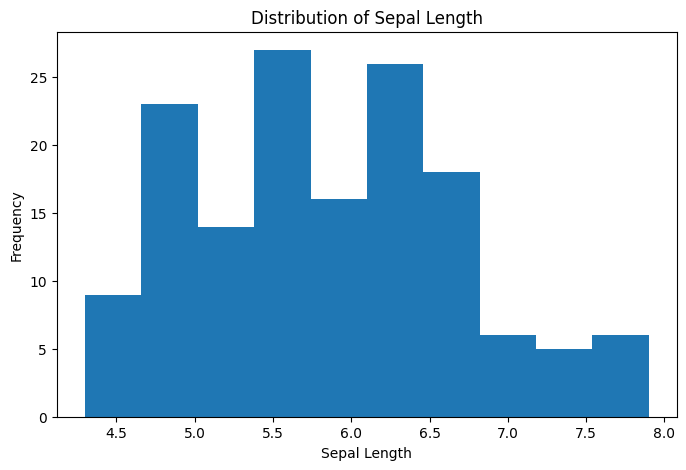

In [6]:
# CREATE HISTOGRAM
plt.figure(figsize=(8,5))

plt.hist(df['sepal_length'], bins=10)

plt.title("Distribution of Sepal Length")
plt.xlabel("Sepal Length")
plt.ylabel("Frequency")

# Save visualization
plt.savefig("../visuals/histogram.png")

plt.show()

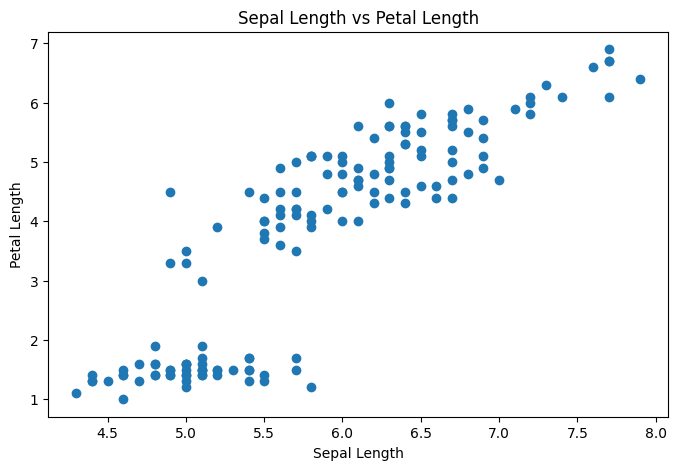

In [7]:
# SCATTER PLOT
plt.figure(figsize=(8,5))

plt.scatter(
    df['sepal_length'],
    df['petal_length']
)

plt.title("Sepal Length vs Petal Length")
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")

# Save visualization
plt.savefig("../visuals/scatterplot.png")

plt.show()

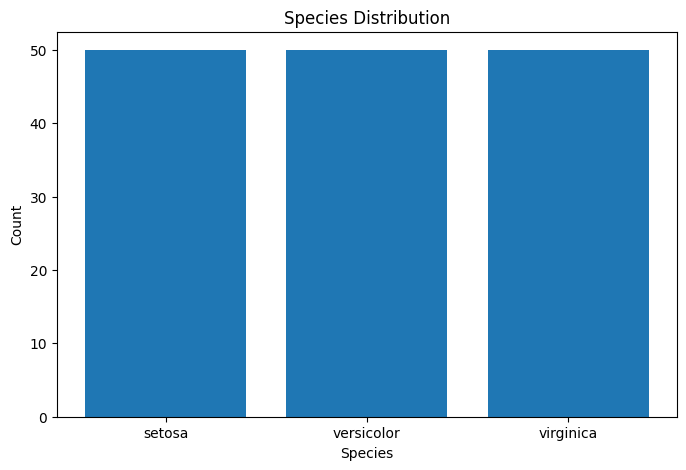

In [8]:
# SPECIES DISTRIBUTION(Create Bar Chart)
species_counts = df['species'].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    species_counts.index,
    species_counts.values
)

plt.title("Species Distribution")
plt.xlabel("Species")
plt.ylabel("Count")

# Save visualization
plt.savefig("../visuals/species_distribution.png")

plt.show()

Correlation Matrix:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length          1.00        -0.12          0.87         0.82
sepal_width          -0.12         1.00         -0.43        -0.37
petal_length          0.87        -0.43          1.00         0.96
petal_width           0.82        -0.37          0.96         1.00

Heatmap saved to: visuals/correlation_heatmap.png


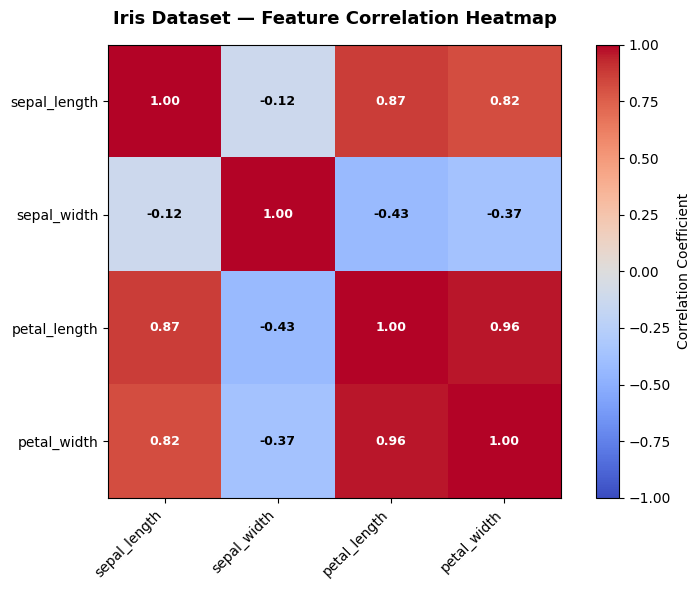

In [9]:
# CORRELATION HEATMAP
# Shows the relationship strength between all numerical features

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Select only the numerical columns from the dataset, exclude 'species'
numerical_df = df.select_dtypes(include='number')

# Step 2: Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Print the matrix to read the exact values
print("Correlation Matrix:")
print(correlation_matrix.round(2))

# Create the heatmap figure
fig, ax = plt.subplots(figsize=(8, 6))  # Set canvas size

# Display the correlation matrix as a colour grid
heatmap = ax.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)

# Add a colour bar on the right side to explain what the colours mean
plt.colorbar(heatmap, ax=ax, label='Correlation Coefficient')

# Label the X and Y axes with column names
feature_names = correlation_matrix.columns.tolist()
ax.set_xticks(range(len(feature_names)))
ax.set_yticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(feature_names, fontsize=10)

# Print the correlation value inside each cell of the grid
for i in range(len(feature_names)):
    for j in range(len(feature_names)):
        value = correlation_matrix.iloc[i, j]
        # Use black text on light cells, white text on dark cells
        text_color = 'black' if abs(value) < 0.7 else 'white'
        ax.text(j, i, f'{value:.2f}', ha='center', va='center',
                fontsize=9, color=text_color, fontweight='bold')

# Add title and layout polish
ax.set_title('Iris Dataset — Feature Correlation Heatmap', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()

# Save the chart to the visuals folder
plt.savefig('../visuals/correlation_heatmap.png', dpi=150, bbox_inches='tight')
print("\nHeatmap saved to: visuals/correlation_heatmap.png")

plt.show()

In [10]:
# SEABORN VISUALIZATIONS

import seaborn as sns
import matplotlib.pyplot as plt

# Apply visual theme to all Seaborn charts
sns.set_theme(style='whitegrid', palette='muted')

print("Seaborn version:", sns.__version__)
print("Starting Seaborn visualizations...\n")

Seaborn version: 0.13.2
Starting Seaborn visualizations...



Pair plot saved to: visuals/seaborn_pairplot.png


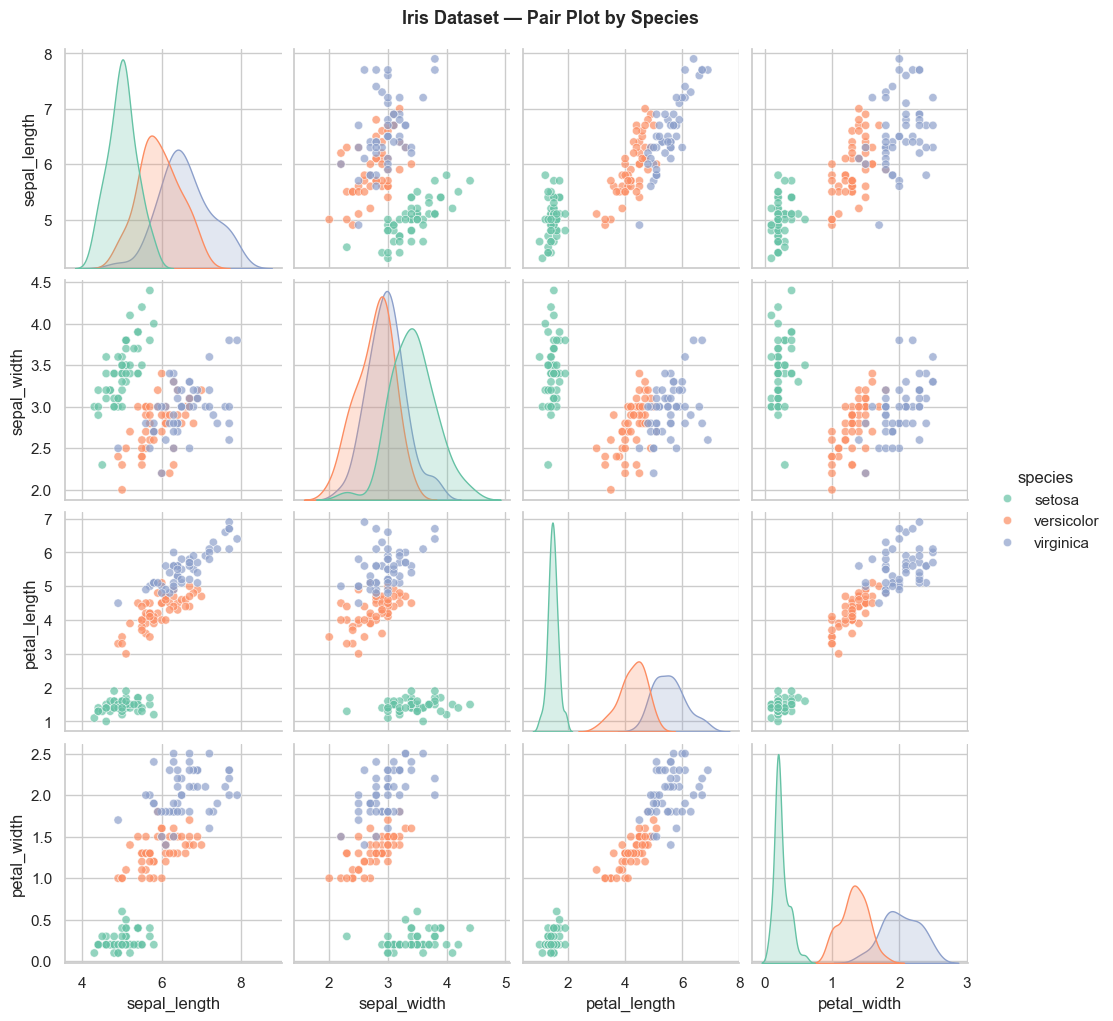

In [11]:
# SEABORN CHART 1: PAIR PLOT
# Shows scatter plots for every combination of numerical features

pair_plot = sns.pairplot(
    df,                          # The full dataset
    hue='species',               # Colour-code points by species
    diag_kind='kde',             # On the diagonal, show a smooth curve (KDE) instead of scatter
    plot_kws={'alpha': 0.7},     # Make points slightly transparent so overlaps are visible
    palette='Set2'               # Colour palette (green, orange, blue)
)

pair_plot.figure.suptitle('Iris Dataset — Pair Plot by Species', y=1.02, fontsize=13, fontweight='bold')

# Save the pair plot
pair_plot.savefig('../visuals/seaborn_pairplot.png', dpi=150, bbox_inches='tight')
print("Pair plot saved to: visuals/seaborn_pairplot.png")

plt.show()

Violin plot saved to: visuals/seaborn_violin.png


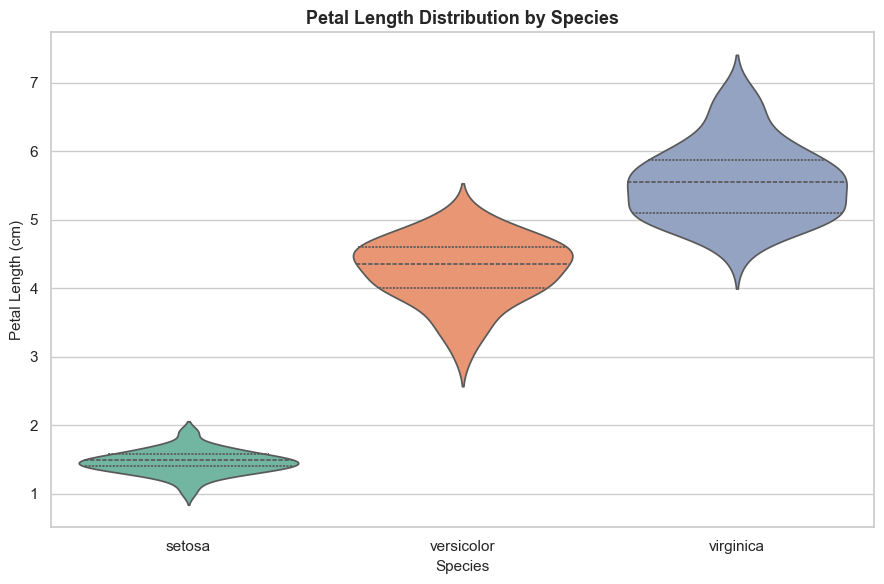

In [12]:
# SEABORN CHART 2: VIOLIN PLOT
# Shows how petal length is distributed across each species

fig, ax = plt.subplots(figsize=(9, 6))

sns.violinplot(
    data=df,
    x='species',           # X-axis: flower species
    y='petal_length',      # Y-axis: petal length measurement
    hue='species',         # Colour each violin by species
    palette='Set2',        # Colour palette
    inner='quartile',      # Draw quartile lines inside each violin
    legend=False,          # Hide the legend (species labels are already on X-axis)
    ax=ax
)

ax.set_title('Petal Length Distribution by Species', fontsize=13, fontweight='bold')
ax.set_xlabel('Species', fontsize=11)
ax.set_ylabel('Petal Length (cm)', fontsize=11)

plt.tight_layout()
plt.savefig('../visuals/seaborn_violin.png', dpi=150, bbox_inches='tight')
print("Violin plot saved to: visuals/seaborn_violin.png")

plt.show()

Box plot saved to: visuals/seaborn_boxplot.png


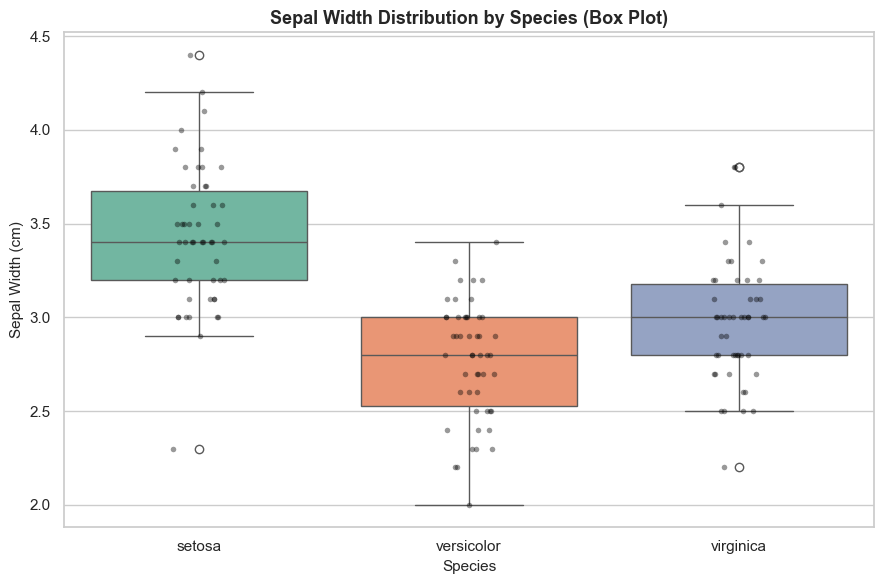

In [13]:
# SEABORN CHART 3: BOX PLOT
# Displays the median, quartiles, and outliers for sepal width

fig, ax = plt.subplots(figsize=(9, 6))

sns.boxplot(
    data=df,
    x='species',
    y='sepal_width',
    hue='species',
    palette='Set2',
    legend=False,
    ax=ax
)

# Overlay individual data points so you can see raw values
sns.stripplot(
    data=df,
    x='species',
    y='sepal_width',
    color='black',       # Black dots for contrast
    alpha=0.4,           # Slight transparency
    size=4,
    ax=ax
)

ax.set_title('Sepal Width Distribution by Species (Box Plot)', fontsize=13, fontweight='bold')
ax.set_xlabel('Species', fontsize=11)
ax.set_ylabel('Sepal Width (cm)', fontsize=11)

plt.tight_layout()
plt.savefig('../visuals/seaborn_boxplot.png', dpi=150, bbox_inches='tight')
print("Box plot saved to: visuals/seaborn_boxplot.png")

plt.show()

Seaborn heatmap saved to: visuals/seaborn_heatmap.png


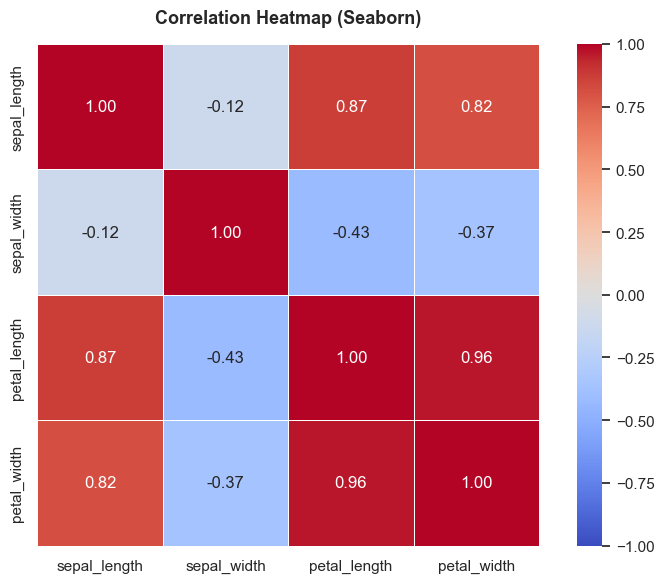

In [14]:
# SEABORN CHART 4: CORRELATION HEATMAP (Seaborn version)
# Seaborn produces a cleaner heatmap with less code

fig, ax = plt.subplots(figsize=(8, 6))

correlation_matrix = df.select_dtypes(include='number').corr()

sns.heatmap(
    correlation_matrix,
    annot=True,            # Print the correlation value inside each cell
    fmt='.2f',             # Format values to 2 decimal places
    cmap='coolwarm',       # Colour map: blue → white → red
    vmin=-1, vmax=1,       # Colour range
    linewidths=0.5,        # Add thin lines between cells
    square=True,           # Make cells square-shaped
    ax=ax
)

ax.set_title('Correlation Heatmap (Seaborn)', fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../visuals/seaborn_heatmap.png', dpi=150, bbox_inches='tight')
print("Seaborn heatmap saved to: visuals/seaborn_heatmap.png")

plt.show()

In [15]:
## Machine Learning Classification Models

In [16]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Prepare the data
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['species']

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Train all three models
lr_model = LogisticRegression(max_iter=200, random_state=42)
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

# Accuracy summary
print("=" * 45)
print("MODEL ACCURACY COMPARISON")
print("=" * 45)
print(f"Logistic Regression: {accuracy_score(y_test, lr_predictions) * 100:.2f}%")
print(f"Decision Tree:       {accuracy_score(y_test, dt_predictions) * 100:.2f}%")
print(f"Random Forest:       {accuracy_score(y_test, rf_predictions) * 100:.2f}%")
print("=" * 45)
print("\nSetup complete — rf_model, encoder, X_test, y_test are ready.")

MODEL ACCURACY COMPARISON
Logistic Regression: 96.67%
Decision Tree:       93.33%
Random Forest:       90.00%

Setup complete — rf_model, encoder, X_test, y_test are ready.


In [17]:
# DATA PREPARATION

# Separate features (X) from the label (y)
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['species']

# Convert species text labels to numbers
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("Original labels:", y.unique())
print("Encoded labels: ", encoder.transform(y.unique()))

# Split the data into training set and test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"\nTraining set size: {X_train.shape[0]} rows")
print(f"Test set size:     {X_test.shape[0]} rows")

Original labels: <ArrowStringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str
Encoded labels:  [0 1 2]

Training set size: 120 rows
Test set size:     30 rows


In [18]:
# TRAIN THREE MODELS

# Model 1: Logistic Regression
# max_iter=200 gives the model enough training cycles to converge
lr_model = LogisticRegression(max_iter=200, random_state=42)
lr_model.fit(X_train, y_train)           # Train on training data
lr_predictions = lr_model.predict(X_test) # Predict on test data
lr_accuracy = accuracy_score(y_test, lr_predictions)

# Model 2: Decision Tree
# max_depth=4 limits how deep the tree grows (prevents overfitting)
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_predictions)

# Model 3: Random Forest
# n_estimators=100 means 100 individual trees are built and combined
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)

# Print accuracy for all three
print("=" * 45)
print("MODEL ACCURACY COMPARISON")
print("=" * 45)
print(f"Logistic Regression: {lr_accuracy * 100:.2f}%")
print(f"Decision Tree:       {dt_accuracy * 100:.2f}%")
print(f"Random Forest:       {rf_accuracy * 100:.2f}%")
print("=" * 45)

MODEL ACCURACY COMPARISON
Logistic Regression: 96.67%
Decision Tree:       93.33%
Random Forest:       90.00%


In [19]:
# CLASSIFICATION REPORT

print("\nDetailed Report — Random Forest (typically most accurate):\n")
print(classification_report(
    y_test,
    rf_predictions,
    target_names=encoder.classes_  # Show species names instead of numbers
))


Detailed Report — Random Forest (typically most accurate):

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



Feature importance chart saved to: visuals/feature_importance.png


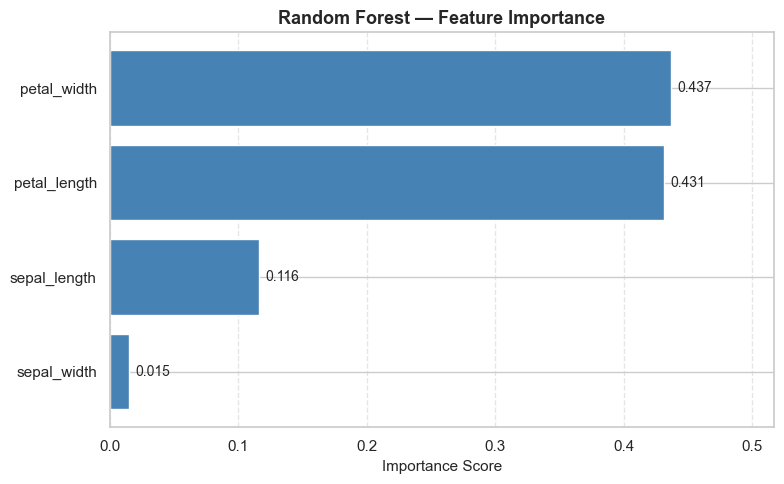

In [20]:
# FEATURE IMPORTANCE

feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
importances = rf_model.feature_importances_  # Built-in attribute of Random Forest

# Sort features from most to least important
sorted_indices = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in sorted_indices]
sorted_importances = importances[sorted_indices]

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(sorted_features[::-1], sorted_importances[::-1], color='steelblue', edgecolor='white')

# Add value labels on each bar
for bar, val in zip(bars, sorted_importances[::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=10)

ax.set_title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_xlim(0, max(importances) + 0.08)
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../visuals/feature_importance.png', dpi=150, bbox_inches='tight')
print("Feature importance chart saved to: visuals/feature_importance.png")

plt.show()

In [21]:
# MAKE A PREDICTION ON NEW DATA

# Define the new flower as a DataFrame with named columns
new_flower = pd.DataFrame(
    [[5.1, 2.5, 3.0, 1.1]],
    columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
)

# Predict species
prediction_encoded = rf_model.predict(new_flower)
prediction_label = encoder.inverse_transform(prediction_encoded)

print("New Flower Measurements:")
print(f"  Sepal Length: {new_flower['sepal_length'].values[0]} cm")
print(f"  Sepal Width:  {new_flower['sepal_width'].values[0]} cm")
print(f"  Petal Length: {new_flower['petal_length'].values[0]} cm")
print(f"  Petal Width:  {new_flower['petal_width'].values[0]} cm")
print(f"\nPredicted Species: {prediction_label[0].upper()}")

# Probability breakdown
probabilities = rf_model.predict_proba(new_flower)[0]
print("\nProbability Breakdown:")
for species, prob in zip(encoder.classes_, probabilities):
    print(f"  {species:<12}: {prob * 100:.1f}%")

New Flower Measurements:
  Sepal Length: 5.1 cm
  Sepal Width:  2.5 cm
  Petal Length: 3.0 cm
  Petal Width:  1.1 cm

Predicted Species: VERSICOLOR

Probability Breakdown:
  setosa      : 1.0%
  versicolor  : 98.0%
  virginica   : 1.0%


# Key Insights

## Statistical Findings

- The average sepal length of the flowers is approximately **5.56 cm**.
- The average petal length is approximately **3.30 cm**.
- The most common flower species in the dataset is **Setosa**.
- The largest sepal length recorded in the dataset is **7.60 cm**.

## Data Quality Observations

- No missing values were detected in the dataset.
- The dataset is clean and properly structured for analysis.

## Analytical Insights

- Flowers with larger sepals generally tend to have larger petals.
- Setosa flowers appear to have smaller petal measurements compared to other species.
- The dataset demonstrates visible variation between flower species, making it suitable for classification and predictive analysis tasks.

## Business / Analytical Value

This exploratory data analysis demonstrates important data analyst skills including:

- statistical analysis
- data exploration
- visualization
- insight generation
- pattern identification
- analytical reporting